# Phase 1b - Random Forest and XGBoost Benchmarks

**Purpose.** Add stronger tree-ensemble baselines to the Phase 1 Luh & Blank
benchmark before moving to Phase 4b SOH transfer.

This notebook uses the same processed Phase 1 CSVs:

- `phase2_train.csv`
- `phase2_val.csv`
- `phase2_test.csv`

It evaluates:

- Random Forest pointwise: current features -> `[Q, Re]`
- XGBoost pointwise: current features -> `[Q, Re]`
- Random Forest autoregressive rollout: current features + previous predicted `[Q, Re]`
- XGBoost autoregressive rollout: current features + previous predicted `[Q, Re]`

The autoregressive variants are deployment-style tabular baselines: each cell is
seeded with the first measured health point, then subsequent `Q_prev/Re_prev`
inputs are replaced by the model's own predictions.



## 0. Imports and Config



In [52]:
import os
import json
import random
import time
import warnings
import zipfile
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception as exc:
    HAS_XGB = False
    XGB_IMPORT_ERROR = repr(exc)

SEED = 42
WORKING = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
WORKING.mkdir(parents=True, exist_ok=True)
RUN_FAST = bool(int(os.environ.get("PHASE1_TREE_FAST", "0")))
RUN_TAG = "phase1_rf_xgboost_" + datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = WORKING / RUN_TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_FEATS_9 = [
    "k_exp",
    "temperature",
    "c_rate_chg",
    "c_rate_dischg",
    "soc_window",
    "age_type",
    "Q0",
    "Re0",
    "Rct0",
]
TARGETS = ["Q", "Re"]
AR_FEATS = RAW_FEATS_9 + ["Q_prev", "Re_prev"]

PHASE1_REFERENCE = {
    "LSTM_v1_teacher_forced_macro_mape": 1.405,
    "LSTM_v4_rollout_tuned_macro_mape": 1.551,
    "Tree_pointwise_macro_mape": 7.326,
    "PINN_phys_macro_mape": 6.830,
}

random.seed(SEED)
np.random.seed(SEED)

print("=" * 72)
print("Phase 1b - RF/XGBoost Benchmarks")
print("=" * 72)
print(f"RUN_FAST : {RUN_FAST}")
print(f"HAS_XGB  : {HAS_XGB}")
if not HAS_XGB:
    print(f"XGBoost import error: {XGB_IMPORT_ERROR}")
print(f"Output   : {OUT_DIR}")



Phase 1b - RF/XGBoost Benchmarks
RUN_FAST : False
HAS_XGB  : True
Output   : /kaggle/working/phase1_rf_xgboost_20260625_070613


## 1. Utilities



In [53]:
metrics_rows = []
pred_frames = []
train_times = {}


def print_section(title, char="="):
    print("\n" + char * 72)
    print(title)
    print(char * 72)


def print_kv(label, value, width=28):
    print(f"{label:<{width}} : {value}")


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.clip(np.abs(y_true), 1e-8, None)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)


def nrmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.clip(np.max(y_true) - np.min(y_true), 1e-8, None)
    return float(rmse / denom)


def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 3 or np.nanvar(y_true) <= 1e-12:
        return np.nan
    return float(r2_score(y_true, y_pred))


def per_target_metrics(y_true, y_pred):
    rows = []
    for j, target in enumerate(TARGETS):
        rows.append(
            {
                "target": target,
                "MAPE": mape(y_true[:, j], y_pred[:, j]),
                "RMSE": float(np.sqrt(mean_squared_error(y_true[:, j], y_pred[:, j]))),
                "NRMSE": nrmse(y_true[:, j], y_pred[:, j]),
                "R2": safe_r2(y_true[:, j], y_pred[:, j]),
            }
        )
    rows.append(
        {
            "target": "macro_avg",
            "MAPE": float(np.mean([r["MAPE"] for r in rows])),
            "RMSE": float(np.mean([r["RMSE"] for r in rows])),
            "NRMSE": float(np.mean([r["NRMSE"] for r in rows])),
            "R2": float(np.nanmean([r["R2"] for r in rows])),
        }
    )
    return pd.DataFrame(rows)


def record_metrics(model_name, split, y_true, y_pred, protocol, feature_set):
    dfm = per_target_metrics(y_true, y_pred)
    for _, row in dfm.iterrows():
        metrics_rows.append(
            {
                "model": model_name,
                "split": split,
                "target": row["target"],
                "protocol": protocol,
                "feature_set": feature_set,
                "MAPE": row["MAPE"],
                "RMSE": row["RMSE"],
                "NRMSE": row["NRMSE"],
                "R2": row["R2"],
            }
        )
    macro = dfm[dfm["target"] == "macro_avg"].iloc[0]
    print(
        f"{model_name:<32s} {split:<5s} {protocol:<12s} "
        f"macro MAPE={macro['MAPE']:.4f}% R2={macro['R2']:.4f}"
    )
    return dfm


def slugify(text):
    keep = []
    for ch in str(text).lower():
        if ch.isalnum():
            keep.append(ch)
        elif ch in [" ", "_", "-", "+", "/"]:
            keep.append("_")
    return "_".join("".join(keep).split("_")).strip("_")



## 2. Data Loading



In [54]:
def discover_pack_dir():
    fixed_candidates = [
        "/kaggle/input/datasets/simhaatt/outputs-of-luh-and-blank",
        "/kaggle/input/outputs-of-luh-and-blank",
        "/kaggle/input/battery-outputs/outputs-of-luh-and-blank",
        "/kaggle/working",
        ".",
    ]
    for c in fixed_candidates:
        p = Path(c)
        if (p / "phase2_train.csv").exists() and (p / "phase2_val.csv").exists() and (p / "phase2_test.csv").exists():
            return p
    roots = [Path("/kaggle/input"), WORKING, Path(".")]
    for root in roots:
        if not root.exists():
            continue
        for hit in sorted(root.glob("**/phase2_train.csv")):
            p = hit.parent
            if (p / "phase2_val.csv").exists() and (p / "phase2_test.csv").exists():
                return p
    raise FileNotFoundError("Could not find phase2_train.csv, phase2_val.csv, and phase2_test.csv")


pack_dir = discover_pack_dir()
print_section("Data Loading")
print_kv("Pack dir", pack_dir)

train_df = pd.read_csv(pack_dir / "phase2_train.csv")
val_df = pd.read_csv(pack_dir / "phase2_val.csv")
test_df = pd.read_csv(pack_dir / "phase2_test.csv")

required = set(["cell_id"] + RAW_FEATS_9 + TARGETS)
missing = sorted(required - set(train_df.columns))
if missing:
    raise ValueError(f"Missing required columns: {missing}")

for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print_kv(name, f"{df.shape} ({df['cell_id'].nunique()} cells)")




Data Loading
Pack dir                     : /kaggle/input/datasets/simhaatt/outputs-of-luh-and-blank
Train                        : (3186, 20) (180 cells)
Val                          : (395, 20) (27 cells)
Test                         : (399, 20) (21 cells)


## 3. Feature Builders



In [55]:
def build_pointwise(df, feats):
    x = df[feats].values.astype(np.float32)
    y = df[TARGETS].values.astype(np.float32)
    meta = df[["cell_id", "k_exp"]].copy()
    return x, y, meta


def add_prev_targets(df):
    parts = []
    for _, g in df.groupby("cell_id"):
        g = g.sort_values("k_exp").reset_index(drop=True).copy()
        g["Q_prev"] = g["Q"].shift(1)
        g["Re_prev"] = g["Re"].shift(1)
        parts.append(g.iloc[1:].copy())
    return pd.concat(parts, ignore_index=True)


def build_autoreg_training(df, feats=AR_FEATS):
    ar = add_prev_targets(df)
    x = ar[feats].values.astype(np.float32)
    y = ar[TARGETS].values.astype(np.float32)
    meta = ar[["cell_id", "k_exp"]].copy()
    return x, y, meta


def rollout_autoreg(model, df, feats=AR_FEATS):
    preds = []
    truth = []
    meta_rows = []
    for cid, g in df.groupby("cell_id"):
        g = g.sort_values("k_exp").reset_index(drop=True).copy()
        if len(g) < 2:
            continue
        q_prev = float(g.loc[0, "Q"])
        re_prev = float(g.loc[0, "Re"])
        for i in range(1, len(g)):
            row = g.iloc[i].copy()
            row["Q_prev"] = q_prev
            row["Re_prev"] = re_prev
            x = row[feats].values.astype(np.float32).reshape(1, -1)
            yp = np.asarray(model.predict(x), dtype=float).reshape(1, -1)[0]
            yp = np.clip(yp, [1e-6, 1e-9], None)
            preds.append(yp)
            truth.append(row[TARGETS].values.astype(np.float32))
            meta_rows.append({"cell_id": cid, "k_exp": float(row["k_exp"])})
            q_prev, re_prev = float(yp[0]), float(yp[1])
    return np.asarray(truth, dtype=np.float32), np.asarray(preds, dtype=np.float32), pd.DataFrame(meta_rows)



## 4. Model Factories and Config Search



In [56]:
def make_rf(cfg):
    return RandomForestRegressor(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        min_samples_leaf=cfg["min_samples_leaf"],
        max_features=cfg["max_features"],
        random_state=SEED,
        n_jobs=-1,
    )


def make_extra_trees(cfg):
    return ExtraTreesRegressor(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        min_samples_leaf=cfg["min_samples_leaf"],
        max_features=cfg["max_features"],
        random_state=SEED,
        n_jobs=-1,
    )


def make_xgb(cfg):
    base = XGBRegressor(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        learning_rate=cfg["learning_rate"],
        subsample=cfg["subsample"],
        colsample_bytree=cfg["colsample_bytree"],
        reg_lambda=cfg["reg_lambda"],
        objective="reg:squarederror",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1,
    )
    return MultiOutputRegressor(base)


RF_GRID = [
    {"n_estimators": 400, "max_depth": 12, "min_samples_leaf": 2, "max_features": 0.8},
    {"n_estimators": 600, "max_depth": 16, "min_samples_leaf": 2, "max_features": 0.8},
    {"n_estimators": 600, "max_depth": None, "min_samples_leaf": 3, "max_features": 0.7},
]
ET_GRID = [
    {"n_estimators": 500, "max_depth": 16, "min_samples_leaf": 2, "max_features": 0.8},
    {"n_estimators": 700, "max_depth": None, "min_samples_leaf": 3, "max_features": 0.7},
]
XGB_GRID = [
    {"n_estimators": 600, "max_depth": 3, "learning_rate": 0.03, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 2.0},
    {"n_estimators": 800, "max_depth": 4, "learning_rate": 0.025, "subsample": 0.9, "colsample_bytree": 0.8, "reg_lambda": 3.0},
    {"n_estimators": 500, "max_depth": 5, "learning_rate": 0.035, "subsample": 0.85, "colsample_bytree": 0.85, "reg_lambda": 4.0},
]

if RUN_FAST:
    RF_GRID = RF_GRID[:1]
    ET_GRID = ET_GRID[:1]
    XGB_GRID = XGB_GRID[:1]


def fit_select(model_family, factory, grid, xtr, ytr, xvl, yvl, protocol):
    best_model, best_cfg, best_val = None, None, float("inf")
    for i, cfg in enumerate(grid, 1):
        t0 = time.time()
        model = factory(cfg)
        model.fit(xtr, ytr)
        yp_v = np.clip(model.predict(xvl), [1e-6, 1e-9], None)
        val_macro = float(per_target_metrics(yvl, yp_v).query("target == 'macro_avg'")["MAPE"].iloc[0])
        dt = time.time() - t0
        flag = " <==" if val_macro < best_val else ""
        print(f"{model_family} {protocol} [{i}/{len(grid)}] val={val_macro:.4f}% time={dt:.1f}s cfg={cfg}{flag}")
        if val_macro < best_val:
            best_model, best_cfg, best_val = model, cfg, val_macro
    return best_model, best_cfg, best_val



## 5. Pointwise Benchmarks



In [57]:
POINTWISE_FEATURE_SETS = {
    "full9": RAW_FEATS_9,
    "sparse_k_Re0": ["k_exp", "Re0"],
    "sparse_k_Re0_Q0": ["k_exp", "Re0", "Q0"],
    "sparse_k_Re0_Rct0_Q0": ["k_exp", "Re0", "Rct0", "Q0"],
}

model_artifacts = []

for feature_set_name, feats in POINTWISE_FEATURE_SETS.items():
    print_section(f"Pointwise Feature Set: {feature_set_name}")
    xtr, ytr, _ = build_pointwise(train_df, feats)
    xvl, yvl, _ = build_pointwise(val_df, feats)
    xte, yte, meta_te = build_pointwise(test_df, feats)

    for model_family, factory, grid in [
        ("RF", make_rf, RF_GRID),
        ("ExtraTrees", make_extra_trees, ET_GRID),
    ]:
        t0 = time.time()
        model, cfg, _ = fit_select(model_family, factory, grid, xtr, ytr, xvl, yvl, "pointwise")
        train_times[f"{model_family}_pointwise_{feature_set_name}"] = time.time() - t0
        for split, x, y in [("val", xvl, yvl), ("test", xte, yte)]:
            yp = np.clip(model.predict(x), [1e-6, 1e-9], None)
            record_metrics(f"{model_family}_pointwise", split, y, yp, "pointwise", feature_set_name)

    if HAS_XGB:
        t0 = time.time()
        model, cfg, _ = fit_select("XGBoost", make_xgb, XGB_GRID, xtr, ytr, xvl, yvl, "pointwise")
        train_times[f"XGBoost_pointwise_{feature_set_name}"] = time.time() - t0
        for split, x, y in [("val", xvl, yvl), ("test", xte, yte)]:
            yp = np.clip(model.predict(x), [1e-6, 1e-9], None)
            record_metrics("XGBoost_pointwise", split, y, yp, "pointwise", feature_set_name)




Pointwise Feature Set: full9
RF pointwise [1/3] val=6.3480% time=1.1s cfg={'n_estimators': 400, 'max_depth': 12, 'min_samples_leaf': 2, 'max_features': 0.8} <==
RF pointwise [2/3] val=6.4272% time=1.8s cfg={'n_estimators': 600, 'max_depth': 16, 'min_samples_leaf': 2, 'max_features': 0.8}
RF pointwise [3/3] val=6.2443% time=1.6s cfg={'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': 0.7} <==
RF_pointwise                     val   pointwise    macro MAPE=6.2443% R2=0.4733
RF_pointwise                     test  pointwise    macro MAPE=6.6070% R2=0.6081
ExtraTrees pointwise [1/2] val=5.7166% time=0.9s cfg={'n_estimators': 500, 'max_depth': 16, 'min_samples_leaf': 2, 'max_features': 0.8} <==
ExtraTrees pointwise [2/2] val=5.9404% time=1.2s cfg={'n_estimators': 700, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': 0.7}
ExtraTrees_pointwise             val   pointwise    macro MAPE=5.7166% R2=0.5520
ExtraTrees_pointwise             test  pointwise    mac

## 6. Autoregressive Rollout Benchmarks



In [58]:
AR_FEATURE_SETS = {
    "full9_prevQR": RAW_FEATS_9 + ["Q_prev", "Re_prev"],
    "sparse_k_Re0_prevQR": ["k_exp", "Re0", "Q_prev", "Re_prev"],
    "sparse_k_Re0_Q0_prevQR": ["k_exp", "Re0", "Q0", "Q_prev", "Re_prev"],
    "sparse_k_Re0_Rct0_Q0_prevQR": ["k_exp", "Re0", "Rct0", "Q0", "Q_prev", "Re_prev"],
}

for feature_set_name, feats in AR_FEATURE_SETS.items():
    print_section(f"Autoregressive Feature Set: {feature_set_name}")
    xtr, ytr, _ = build_autoreg_training(train_df, feats)
    xvl, yvl, _ = build_autoreg_training(val_df, feats)

    for model_family, factory, grid in [
        ("RF", make_rf, RF_GRID),
        ("ExtraTrees", make_extra_trees, ET_GRID),
    ]:
        t0 = time.time()
        model, cfg, _ = fit_select(model_family, factory, grid, xtr, ytr, xvl, yvl, "ar-direct")
        train_times[f"{model_family}_rollout_{feature_set_name}"] = time.time() - t0
        for split, df in [("val", val_df), ("test", test_df)]:
            y_true, y_pred, meta = rollout_autoreg(model, df, feats)
            record_metrics(f"{model_family}_rollout", split, y_true, y_pred, "autoregressive_rollout", feature_set_name)

    if HAS_XGB:
        t0 = time.time()
        model, cfg, _ = fit_select("XGBoost", make_xgb, XGB_GRID, xtr, ytr, xvl, yvl, "ar-direct")
        train_times[f"XGBoost_rollout_{feature_set_name}"] = time.time() - t0
        for split, df in [("val", val_df), ("test", test_df)]:
            y_true, y_pred, meta = rollout_autoreg(model, df, feats)
            record_metrics("XGBoost_rollout", split, y_true, y_pred, "autoregressive_rollout", feature_set_name)




Autoregressive Feature Set: full9_prevQR
RF ar-direct [1/3] val=1.6655% time=1.6s cfg={'n_estimators': 400, 'max_depth': 12, 'min_samples_leaf': 2, 'max_features': 0.8} <==
RF ar-direct [2/3] val=1.6451% time=2.5s cfg={'n_estimators': 600, 'max_depth': 16, 'min_samples_leaf': 2, 'max_features': 0.8} <==
RF ar-direct [3/3] val=1.7318% time=2.1s cfg={'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': 0.7}
RF_rollout                       val   autoregressive_rollout macro MAPE=5.5916% R2=0.4687
RF_rollout                       test  autoregressive_rollout macro MAPE=8.2284% R2=0.4485
ExtraTrees ar-direct [1/2] val=2.0187% time=1.1s cfg={'n_estimators': 500, 'max_depth': 16, 'min_samples_leaf': 2, 'max_features': 0.8} <==
ExtraTrees ar-direct [2/2] val=2.1790% time=1.3s cfg={'n_estimators': 700, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': 0.7}
ExtraTrees_rollout               val   autoregressive_rollout macro MAPE=5.4938% R2=0.5026
ExtraTrees_ro

## 7. Leaderboard



In [59]:
metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(OUT_DIR / "phase1_rf_xgb_metrics_raw.csv", index=False)

summary = (
    metrics_df.groupby(["model", "protocol", "feature_set", "split", "target"], as_index=False)[["MAPE", "RMSE", "NRMSE", "R2"]]
    .mean()
)
summary.to_csv(OUT_DIR / "phase1_rf_xgb_metrics_summary.csv", index=False)

test_macro = (
    summary[(summary["split"] == "test") & (summary["target"] == "macro_avg")]
    .sort_values("MAPE")
    .reset_index(drop=True)
)
test_macro["Rank"] = np.arange(1, len(test_macro) + 1)
test_macro["Delta_vs_LSTM_v4_1p551"] = test_macro["MAPE"] - PHASE1_REFERENCE["LSTM_v4_rollout_tuned_macro_mape"]
test_macro.to_csv(OUT_DIR / "phase1_rf_xgb_test_leaderboard.csv", index=False)

print_section("Test Leaderboard")
print(test_macro[["Rank", "model", "protocol", "feature_set", "MAPE", "R2", "Delta_vs_LSTM_v4_1p551"]].to_string(index=False))

print_section("Top Target-wise Rows")
targetwise = summary[(summary["split"] == "test") & (summary["target"].isin(TARGETS))]
print(targetwise.sort_values(["target", "MAPE"]).head(20).to_string(index=False))




Test Leaderboard
 Rank                model               protocol                 feature_set      MAPE        R2  Delta_vs_LSTM_v4_1p551
    1         RF_pointwise              pointwise                       full9  6.606965  0.608112                5.055965
    2    XGBoost_pointwise              pointwise                       full9  6.659488  0.632375                5.108488
    3         RF_pointwise              pointwise             sparse_k_Re0_Q0  6.792623  0.567015                5.241623
    4 ExtraTrees_pointwise              pointwise             sparse_k_Re0_Q0  6.884197  0.592419                5.333197
    5 ExtraTrees_pointwise              pointwise                       full9  7.144101  0.570530                5.593101
    6         RF_pointwise              pointwise        sparse_k_Re0_Rct0_Q0  7.190138  0.522504                5.639138
    7 ExtraTrees_pointwise              pointwise        sparse_k_Re0_Rct0_Q0  7.204982  0.550446                5.653982
    8 

## 8. Figures and Export



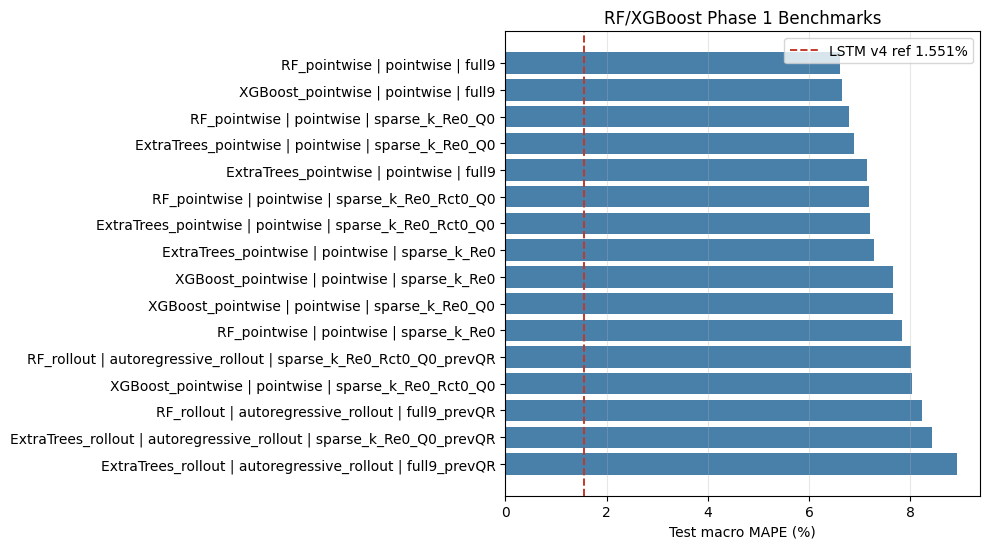

Saved: /kaggle/working/phase1_rf_xgboost_20260625_070613/phase1_rf_xgb_leaderboard.png

Export
Output dir                   : /kaggle/working/phase1_rf_xgboost_20260625_070613
Zip                          : /kaggle/working/phase1_rf_xgboost_20260625_070613.zip
Zip MB                       : 0.18
Key files:
 - /kaggle/working/phase1_rf_xgboost_20260625_070613/phase1_rf_xgb_test_leaderboard.csv
 - /kaggle/working/phase1_rf_xgboost_20260625_070613/phase1_rf_xgb_metrics_summary.csv
 - /kaggle/working/phase1_rf_xgboost_20260625_070613/phase1_rf_xgb_leaderboard.png
 - /kaggle/working/phase1_rf_xgboost_20260625_070613/phase1_rf_xgb_manifest.json


In [60]:
plot_df = test_macro.head(16).copy()
fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(plot_df))))
labels = plot_df["model"] + " | " + plot_df["protocol"] + " | " + plot_df["feature_set"]
ax.barh(labels[::-1], plot_df["MAPE"].values[::-1], color="#2f6f9f", alpha=0.88)
ax.axvline(PHASE1_REFERENCE["LSTM_v4_rollout_tuned_macro_mape"], color="#c0392b", linestyle="--", linewidth=1.4, label="LSTM v4 ref 1.551%")
ax.set_xlabel("Test macro MAPE (%)")
ax.set_title("RF/XGBoost Phase 1 Benchmarks")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
fig_path = OUT_DIR / "phase1_rf_xgb_leaderboard.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

pd.DataFrame(
    [{"model": k, "train_time_s": v} for k, v in train_times.items()]
).to_csv(OUT_DIR / "phase1_rf_xgb_train_times.csv", index=False)

manifest = {
    "run_tag": RUN_TAG,
    "created_at": datetime.now().isoformat(),
    "pack_dir": str(pack_dir),
    "run_fast": RUN_FAST,
    "has_xgboost": HAS_XGB,
    "phase1_reference": PHASE1_REFERENCE,
    "pointwise_feature_sets": POINTWISE_FEATURE_SETS,
    "autoregressive_feature_sets": AR_FEATURE_SETS,
    "files": sorted([p.name for p in OUT_DIR.glob("*")]),
}
with open(OUT_DIR / "phase1_rf_xgb_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

zip_path = WORKING / f"{RUN_TAG}.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for fp in sorted(OUT_DIR.rglob("*")):
        if fp.is_file():
            zf.write(fp, fp.relative_to(OUT_DIR.parent))

print_section("Export")
print_kv("Output dir", OUT_DIR)
print_kv("Zip", zip_path)
print_kv("Zip MB", f"{zip_path.stat().st_size / 1024 / 1024:.2f}")
print("Key files:")
for name in [
    "phase1_rf_xgb_test_leaderboard.csv",
    "phase1_rf_xgb_metrics_summary.csv",
    "phase1_rf_xgb_leaderboard.png",
    "phase1_rf_xgb_manifest.json",
]:
    print(" -", OUT_DIR / name)



## 9. Interpretation

- If any RF/XGBoost rollout row beats 1.551% macro MAPE, it becomes a serious
  Phase 1 challenger and must be included in the main benchmark table.
- If pointwise XGBoost/RF are strong but rollout variants fail, report them as
  tabular interpolation baselines rather than deployment models.
- If none beat LSTM v4, the LSTM remains the strongest deployment-realistic
  model, and the paper gains reviewer-proof tree-ensemble controls.
